# BiLSTM Model dan Training FastText Embeddings

In [ ]:
import sys
import os

# Detect Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research'
    os.chdir(PROJECT_ROOT)
    print(f"Running in Google Colab. Current dir: {os.getcwd()}")
else:
    # Running locally
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Running locally. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Deep Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers
import gensim
from gensim.models import FastText
import mlflow
import mlflow.tensorflow
import dagshub

sns.set_theme(style='whitegrid')
print("All libraries imported successfully.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab. Current dir: /content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research
All libraries imported successfully.


In [ ]:
# Initialize DagsHub
dagshub.init(repo_owner='raflialfansyah', repo_name='lentera1', mlflow=True)

# Set Experiment and AutoLog
mlflow.set_experiment('BiLSTM_FastText_Urgency_Classification')
mlflow.tensorflow.autolog()

# Start the MLflow run
mlflow.start_run(run_name='BiLSTM_FastText_v2_DagsHub_Run')
print("DagsHub and MLflow initialized and run started.")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=67329c0e-3a3b-40c9-907b-ff8bc4fb90df&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=acee16793627f4c5dc77f522fda6bdac2d3975cd1f0cad731fede685857c111a




Accessing as raflialfansyah

Initialized MLflow to track repo "raflialfansyah/lentera1"

Repository raflialfansyah/lentera1 initialized!

DagsHub and MLflow initialized and run started.


---
## 1. Data Loading — Keep FULL dataset (121k rows)

In [ ]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded. Initial shape: {df.shape}")

# Drop missing values
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape after dropna: {df.shape}")

print("\nClass Distribution (imbalanced — we handle it with class_weights):")
print(df['Urgency'].value_counts())
print(f"\nClass imbalance ratio (Low is minority):")
print(f"  High / Low  = {df['Urgency'].value_counts()['High'] / df['Urgency'].value_counts()['Low']:.2f}x")
print(f"  Medium / Low = {df['Urgency'].value_counts()['Medium'] / df['Urgency'].value_counts()['Low']:.2f}x")



Dataset loaded. Initial shape: (121485, 3)
Shape after dropna: (121485, 3)

Class Distribution (imbalanced — we handle it with class_weights):
Urgency
High      52471
Medium    49583
Low       19431
Name: count, dtype: int64

Class imbalance ratio (Low is minority):
  High / Low  = 2.70x
  Medium / Low = 2.55x


---
## 2. Label Encoding and Data Splitting (80/20) with Stratification

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
df['Urgency_Encoded'] = label_encoder.fit_transform(df['Urgency'])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Splitting 80% Train, 20% Test
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df['Cleaned_Narrative'],
    df['Urgency_Encoded'],
    test_size=0.20,
    random_state=42,
    stratify=df['Urgency_Encoded']
)

print(f"Train size: {len(X_train_texts):,}, Test size: {len(X_test_texts):,}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Train size: 97,188, Test size: 24,297

Training set class distribution:
Urgency_Encoded
0    41977
1    15545
2    39666
Name: count, dtype: int64

Test set class distribution:
Urgency_Encoded
0    10494
1     3886
2     9917
Name: count, dtype: int64


---
## 3. Tokenization — Fit on ALL texts

In [ ]:
max_vocab_size = 20000
max_length = 200

# Fit tokenizer on ALL texts so test vocabulary is not lost
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Cleaned_Narrative'])  # ← all data
print(f"Vocabulary size in all data: {len(tokenizer.word_index):,}")

# Convert texts to sequences and pad them
X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print(f"Padding completed. X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape: {X_test_pad.shape}")

Vocabulary size in all data: 40,620
Padding completed. X_train_pad shape: (97188, 200)
X_test_pad shape: (24297, 200)


---
## 4. FastText Training — Train on ALL texts

In [ ]:
print("Training FastText model on ALL data (121k texts)...")

# Train on ALL texts for richer subword representations
all_sentences = [str(text).split() for text in df['Cleaned_Narrative']]

ft_model = FastText(
    sentences=all_sentences,
    vector_size=200,
    window=7,
    min_count=2,
    workers=4,
    sg=1,
    epochs=50
)
print("FastText training completed.")
print(f"FastText vocabulary size: {len(ft_model.wv):,}")

# Save and log FastText model
ft_model_path = 'fasttext_urgency.model'
ft_model.save(ft_model_path)
mlflow.log_artifact(ft_model_path, artifact_path='fasttext_model')
print('FastText model logged to DagsHub.')


In [ ]:
from gensim.models import FastText
import os

# Path menuju model FastText yang sudah ditraining
ft_model_path = os.path.join(PROJECT_ROOT, 'notebooks', 'fasttext_model_dir', 'fasttext_urgency.model')

print(f"Loading FastText model from {ft_model_path}...")
# Load model
ft_model = FastText.load(ft_model_path)

print("FastText model loaded successfully.")
print(f"FastText vocabulary size: {len(ft_model.wv):,}")


Loading FastText model from /content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research/notebooks/fasttext_model_dir/fasttext_urgency.model...
FastText model loaded successfully.
FastText vocabulary size: 21,072


In [ ]:
# Create Embedding Matrix
word_index = tokenizer.word_index
embedding_dim = 200
num_words = min(max_vocab_size, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

words_found = 0
for word, i in word_index.items():
    if i >= max_vocab_size:
        continue
    try:
        embedding_matrix[i] = ft_model.wv[word]
        words_found += 1
    except KeyError:
        pass

print(f"Embedding matrix created. Shape: {embedding_matrix.shape}")
print(f"Words found in FastText vocabulary: {words_found:,} / {min(num_words - 1, len(word_index)):,}")

Embedding matrix created. Shape: (20000, 200)
Words found in FastText vocabulary: 19,999 / 19,999


---
## 5. Build Simplified BiLSTM Model



In [ ]:
# Define simplified BiLSTM architecture
model = Sequential([
    Embedding(input_dim=num_words,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False,                    # FROZEN
              name='embedding'),

    SpatialDropout1D(0.3),


    Bidirectional(
        LSTM(64, return_sequences=True,
             dropout=0.3),
        name='bilstm'
    ),

    GlobalMaxPooling1D(),

    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.02),
          name='dense_classifier'),

    Dropout(0.5),

    Dense(len(label_encoder.classes_), activation='softmax', name='output')
], name='BiLSTM_FastText_v2')

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
total_params = np.sum([np.prod(v.shape) for v in model.weights])
print(f"\nTrainable params: {trainable_params:,} (only classifier head, embeddings frozen)")
print(f"Total params: {total_params:,}")


Model: "BiLSTM_FastText_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_classifier (Dense)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,000,000 (15.26 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,000,000 (15.26 MB)


Trainable params: 0.0 (only classifier head, embeddings frozen)
Total params: 4,000,000


---
## 6. Phase 1 Training — Frozen Embeddings


In [ ]:

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_array))

print("Class weights (computed from full dataset):")
for label_idx, weight in class_weights_dict.items():
    class_name = label_encoder.inverse_transform([label_idx])[0]
    print(f"  {class_name:>8s} (idx={label_idx}): weight = {weight:.4f}")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_bilstm_fasttext_v2_phase1.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

epochs_phase1 = 100
batch_size = 64

print("\n" + "=" * 60)
print("PHASE 1: Training with frozen embeddings")
print("=" * 60)

history_phase1 = model.fit(
    X_train_pad, y_train,
    epochs=epochs_phase1,
    batch_size=batch_size,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

Class weights (computed from full dataset):
      High (idx=0): weight = 0.7718
       Low (idx=1): weight = 2.0840
    Medium (idx=2): weight = 0.8167

PHASE 1: Training with frozen embeddings


2026/06/10 09:54:13 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Epoch 1/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7756 - loss: 0.5635
Epoch 1: val_loss improved from None to 0.50113, saving model to best_bilstm_fasttext_v2_phase1.keras

Epoch 1: finished saving model to best_bilstm_fasttext_v2_phase1.keras


1519/1519 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.7792 - loss: 0.5598 - val_accuracy: 0.7950 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 2/100
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7853 - loss: 0.5446
Epoch 2: val_loss improved from 0.50113 to 0.46928, saving model to best_bilstm_fasttext_v2_phase1.keras

Epoch 2: finished saving model to best_bilstm_fasttext_v2_phase1.keras


1519/1519 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7878 - loss: 0.5393 - val_accuracy: 0.8097 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 3/100
1517/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7904 - loss: 0.5299
Epoch 3: val_loss improved from 0.46928 to 0.45118, saving model to best_bilstm_fasttext_v2_phase1.keras

Epoch 3: finished saving model to best_bilstm_fasttext_v2_phase1.keras


...

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.8235 - loss: 0.4353 - val_accuracy: 0.8284 - val_loss: 0.4076 - learning_rate: 1.2500e-04
Epoch 20/100
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8228 - loss: 0.4372
Epoch 20: val_loss did not improve from 0.40758
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8248 - loss: 0.4346 - val_accuracy: 0.8275 - val_loss: 0.4082 - learning_rate: 1.2500e-04
Epoch 21/100
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8223 - loss: 0.4365
Epoch 21: val_loss improved from 0.40758 to 0.40250, saving model to best_bilstm_fasttext_v2_phase1.keras

Epoch 21: finished saving model to best_bilstm_fasttext_v2_phase1.keras


1519/1519 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8228 - loss: 0.4336 - val_accuracy: 0.8310 - val_loss: 0.4025 - learning_rate: 1.2500e-04
Epoch 22/100
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8202 - loss: 0.4406
Epoch 22: val_loss did not improve from 0.40250
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8237 - loss: 0.4344 - val_accuracy: 0.8292 - val_loss: 0.4080 - learning_rate: 1.2500e-04
Epoch 23/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8230 - loss: 0.4311
Epoch 23: val_loss did not improve from 0.40250
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8243 - loss: 0.4319 - val_accuracy: 0.8247 - val_loss: 0.4115 - learning_rate: 1.2500e-04
Epoch 24/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8250 - loss: 0.4296
Epoch 24: val_loss did not improve from 0.40250

Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8252 - loss: 0.4300 - val_accuracy: 0.8306 - val_loss: 0.4016 - learning_rate: 6.2500e-05
Epoch 28/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8244 - loss: 0.4307
Epoch 28: val_loss did not improve from 0.40162
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8263 - loss: 0.4291 - val_accuracy: 0.8303 - val_loss: 0.4045 - learning_rate: 6.2500e-05
Epoch 29/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8252 - loss: 0.4281
Epoch 29: val_loss did not improve from 0.40162
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8254 - loss: 0.4284 - val_accuracy: 0.8289 - val_loss: 0.4030 - learning_rate: 6.2500e-05
Epoch 30/100
1517/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8267 - loss: 0.4252
Epoch 30: val_loss did not improve from 0.40162

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.8260 - loss: 0.4268 - val_accuracy: 0.8322 - val_loss: 0.3977 - learning_rate: 3.1250e-05
Epoch 32/100
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8276 - loss: 0.4238
Epoch 32: val_loss did not improve from 0.39774
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.8261 - loss: 0.4266 - val_accuracy: 0.8292 - val_loss: 0.4030 - learning_rate: 3.1250e-05
Epoch 33/100
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8243 - loss: 0.4308
Epoch 33: val_loss did not improve from 0.39774
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8251 - loss: 0.4280 - val_accuracy: 0.8289 - val_loss: 0.4040 - learning_rate: 3.1250e-05
Epoch 34/100
1517/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8261 - loss: 0.4296
Epoch 34: val_loss did not improve from 0.39774

Epoch 34: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 

2026/06/10 10:19:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Phase 1 Results (frozen embeddings)
Phase 1 Test Accuracy: 0.8322 (83.22%)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.85      0.90     10494
         Low       0.57      0.87      0.69      3886
      Medium       0.87      0.80      0.83      9917

    accuracy                           0.83     24297
   macro avg       0.80      0.84      0.81     24297
weighted avg       0.86      0.83      0.84     24297



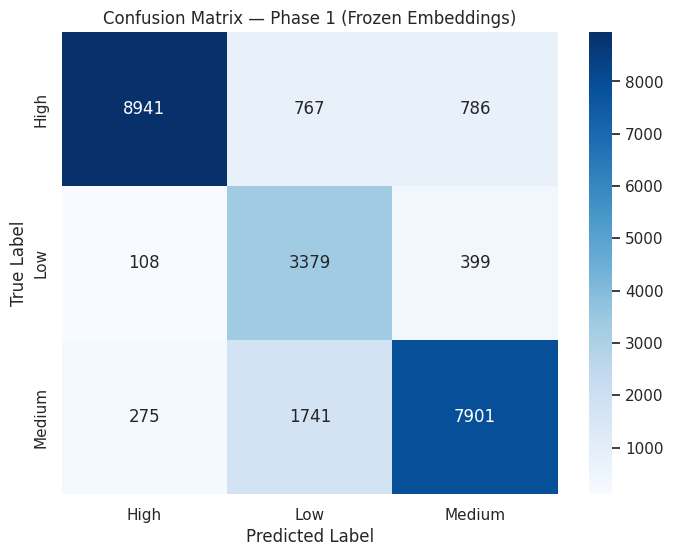

In [ ]:
# Evaluate Phase 1
print("=" * 60)
print("Phase 1 Results (frozen embeddings)")
print("=" * 60)

# Load best weights from Phase 1
model.load_weights('best_bilstm_fasttext_v2_phase1.keras')

y_pred_probs = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

phase1_accuracy = accuracy_score(y_test, y_pred)
print(f"Phase 1 Test Accuracy: {phase1_accuracy:.4f} ({phase1_accuracy*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Phase 1 (Frozen Embeddings)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

---
## 7. Phase 2 Training — Fine-tune Embeddings (Optional)


In [ ]:
# Phase 2: Unfreeze embeddings and fine-tune with very low LR
print("=" * 60)
print("PHASE 2: Fine-tuning embeddings (trainable=True, LR=1e-5)")
print("=" * 60)

# Unfreeze the embedding layer
model.get_layer('embedding').trainable = True

# Recompile with very low learning rate
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # ← very low LR
    metrics=['accuracy']
)

print(f"\nEmbedding trainable: {model.get_layer('embedding').trainable}")
print(f"Learning rate: 1e-5")

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_phase2 = ModelCheckpoint(
    filepath='best_bilstm_fasttext_v2_final.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train with fine-tuning
# Start from where Phase 1 ended, continue training
history_phase2 = model.fit(
    X_train_pad, y_train,
    epochs=50,                          # additional epochs
    batch_size=batch_size,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stopping_phase2, model_checkpoint_phase2, reduce_lr],
    verbose=1
)

PHASE 2: Fine-tuning embeddings (trainable=True, LR=1e-5)

Embedding trainable: True
Learning rate: 1e-5
Epoch 1/50
1517/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8274 - loss: 0.4266
Epoch 1: val_loss improved from None to 0.40221, saving model to best_bilstm_fasttext_v2_final.keras

Epoch 1: finished saving model to best_bilstm_fasttext_v2_final.keras
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.8266 - loss: 0.4258 - val_accuracy: 0.8297 - val_loss: 0.4022 - learning_rate: 1.0000e-05
Epoch 2/50
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8261 - loss: 0.4276
Epoch 2: val_loss did not improve from 0.40221
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8261 - loss: 0.4266 - val_accuracy: 0.8293 - val_loss: 0.4032 - learning_rate: 1.0000e-05
Epoch 3/50
1517/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8270 - loss: 0.4247
Epoch 3: val_loss did not improve from 0.40221

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.99999987

2026/06/10 10:29:55 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


---
## 8. Final Evaluation

In [ ]:
print("=" * 60)
print("FINAL EVALUATION")
print("=" * 60)

# Try loading best Phase 2 model; fall back to Phase 1 if not exists
best_model_path = 'best_bilstm_fasttext_v2_final.keras'
if os.path.exists(best_model_path):
    model.load_weights(best_model_path)
    print(f"Loaded best weights from Phase 2: {best_model_path}")
else:
    model.load_weights('best_bilstm_fasttext_v2_phase1.keras')
    print("Phase 2 did not save a better model. Using Phase 1 best weights.")

# Final predictions
y_pred_probs = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'=' * 60}")
print(f"FINAL TEST ACCURACY: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"{'=' * 60}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Final Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
cm_plot_path = 'final_confusion_matrix.png'
plt.savefig(cm_plot_path)
mlflow.log_artifact(cm_plot_path, artifact_path='evaluation_plots')
plt.show()
print('Confusion matrix plot logged.')

# Per-class metrics
print("\nPer-Class Performance:")
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
# Log classification report
report_text = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
with open('classification_report.txt', 'w') as f:
    f.write(report_text)
mlflow.log_artifact('classification_report.txt', artifact_path='evaluation_metrics')
print('Classification report logged.')

for cls in label_encoder.classes_:
    print(f"  {cls:>8s}: precision={report[cls]['precision']:.4f}, "
          f"recall={report[cls]['recall']:.4f}, "
          f"f1={report[cls]['f1-score']:.4f}, "
          f"support={report[cls]['support']}")

FINAL EVALUATION
Loaded best weights from Phase 2: best_bilstm_fasttext_v2_final.keras


---
## 9. Training History Visualization

In [ ]:
# Combine phase 1 and phase 2 histories
def extract_history(history_obj, prefix=''):
    if history_obj is None:
        return {}, {}
    acc_key = 'accuracy' if 'accuracy' in history_obj.history else 'acc'
    val_acc_key = f'val_{acc_key}'
    return history_obj.history[acc_key], history_obj.history[val_acc_key], history_obj.history['loss'], history_obj.history['val_loss']

# Use only phase 1 if phase 2 didn't run
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
train_acc, val_acc, train_loss, val_loss = extract_history(history_phase1)
epochs_1 = range(1, len(train_acc) + 1)
axes[0].plot(epochs_1, train_acc, 'b-', label='Train Acc (Phase 1)')
axes[0].plot(epochs_1, val_acc, 'r-', label='Val Acc (Phase 1)')

if 'history_phase2' in dir() and history_phase2 is not None:
    train_acc2, val_acc2, _, _ = extract_history(history_phase2)
    epochs_2 = range(len(train_acc) + 1, len(train_acc) + len(train_acc2) + 1)
    axes[0].plot(epochs_2, train_acc2, 'b--', label='Train Acc (Phase 2)')
    axes[0].plot(epochs_2, val_acc2, 'r--', label='Val Acc (Phase 2)')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(epochs_1, train_loss, 'b-', label='Train Loss (Phase 1)')
axes[1].plot(epochs_1, val_loss, 'r-', label='Val Loss (Phase 1)')

if 'history_phase2' in dir() and history_phase2 is not None:
    _, _, train_loss2, val_loss2 = extract_history(history_phase2)
    axes[1].plot(epochs_2, train_loss2, 'b--', label='Train Loss (Phase 2)')
    axes[1].plot(epochs_2, val_loss2, 'r--', label='Val Loss (Phase 2)')

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nNote: If val_loss starts rising while train_loss keeps dropping, the model is overfitting.")
print("The frozen embeddings in Phase 1 should significantly reduce this gap.")

In [ ]:
# Log the final keras models as simple artifacts
if os.path.exists('best_bilstm_fasttext_v2_final.keras'):
    mlflow.log_artifact('best_bilstm_fasttext_v2_final.keras', artifact_path='keras_model_file')
    print('Logged Phase 2 final keras model.')
if os.path.exists('best_bilstm_fasttext_v2_phase1.keras'):
    mlflow.log_artifact('best_bilstm_fasttext_v2_phase1.keras', artifact_path='keras_model_file')
    print('Logged Phase 1 best keras model.')


In [ ]:
# End the MLflow run
mlflow.end_run()
print("MLflow run ended successfully.")